Loading Image Embeddings...
Loading Verification Embeddings...
Running similarity search across 306146 images...


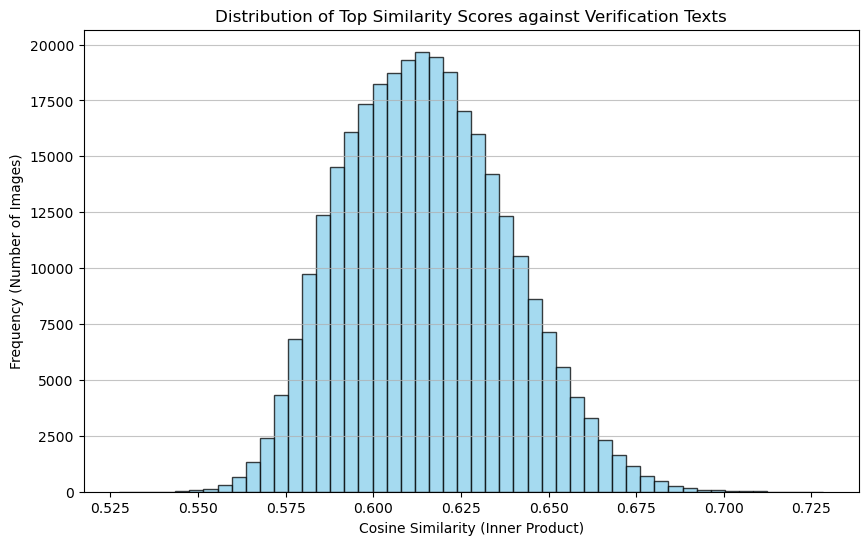


--- Summary by Top Matched Verification Text ---
Class: 'a photo of a plant part'
  Images matched: 10790 (3.5%)
  Mean similarity : 0.624
  Min/Max        : 0.547 / 0.685

Class: 'a photo of a plant'
  Images matched: 4727 (1.5%)
  Mean similarity : 0.627
  Min/Max        : 0.551 / 0.680

Class: 'a photo of NOT a plant'
  Images matched: 12575 (4.1%)
  Mean similarity : 0.619
  Min/Max        : 0.533 / 0.691

Class: 'a photo of a seed'
  Images matched: 54435 (17.8%)
  Mean similarity : 0.607
  Min/Max        : 0.527 / 0.703

Class: 'a photo of a human'
  Images matched: 193 (0.1%)
  Mean similarity : 0.589
  Min/Max        : 0.550 / 0.622

Class: 'a photo of a leaf'
  Images matched: 5892 (1.9%)
  Mean similarity : 0.616
  Min/Max        : 0.556 / 0.678

Class: 'a photo of a fruit'
  Images matched: 29325 (9.6%)
  Mean similarity : 0.622
  Min/Max        : 0.546 / 0.702

Class: 'a photo of a plant organ'
  Images matched: 27254 (8.9%)
  Mean similarity : 0.629
  Min/Max        : 0.5

In [1]:
import faiss
import json
import numpy as np
import matplotlib.pyplot as plt

# Make sure these paths match your notebook's working directory root
img_index_path = "../data/bioclip2_plantnet300k.index"
verification_index_path = "../data/verification.index"
verification_labels_path = "../data/verification_labels.json"

# 1. Load PlantNet Image Embeddings
print("Loading Image Embeddings...")
img_index = faiss.read_index(img_index_path)
img_vectors = img_index.reconstruct_n(0, img_index.ntotal) 

# 2. Load the Newly Created Verification Embeddings
print("Loading Verification Embeddings...")
verif_index = faiss.read_index(verification_index_path)
with open(verification_labels_path, 'r') as f:
    verif_labels = json.load(f)

# 3. Calculate similarities (inner product -> cosine similarity for normalized vectors)
# We search for the top 5 closest text categories for each image vector
k = min(len(verif_labels), 5)
print(f"Running similarity search across {len(img_vectors)} images...")
scores, indices = verif_index.search(img_vectors, k)

# The top match score and index for each image
top_scores = scores[:, 0]
top_labels = np.array([verif_labels[idx] for idx in indices[:, 0]])

# 4. Plot the overall distribution of top-1 similarity scores
plt.figure(figsize=(10, 6))
plt.hist(top_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.75)
plt.title('Distribution of Top Similarity Scores against Verification Texts')
plt.xlabel('Cosine Similarity (Inner Product)')
plt.ylabel('Frequency (Number of Images)')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 5. Break down the score distribution for each text class
print("\n--- Summary by Top Matched Verification Text ---")
unique_classes = set(top_labels)
for cls in unique_classes:
    cls_mask = (top_labels == cls)
    cls_scores = top_scores[cls_mask]
    
    print(f"Class: '{cls}'")
    print(f"  Images matched: {cls_mask.sum()} ({(cls_mask.sum() / len(top_labels))*100:.1f}%)")
    print(f"  Mean similarity : {cls_scores.mean():.3f}")
    print(f"  Min/Max        : {cls_scores.min():.3f} / {cls_scores.max():.3f}\n")


In [3]:
# The JSON file that shares order with the bioclip2_plantnet300k.index
img_meta_path = "../data/bioclip2_plantnet300k_metadata.json"
# Load the image metadata to get the actual file paths
with open(img_meta_path, 'r') as f:
    img_meta = json.load(f)

Plotting top matches for: 'a photo of a dried plant'


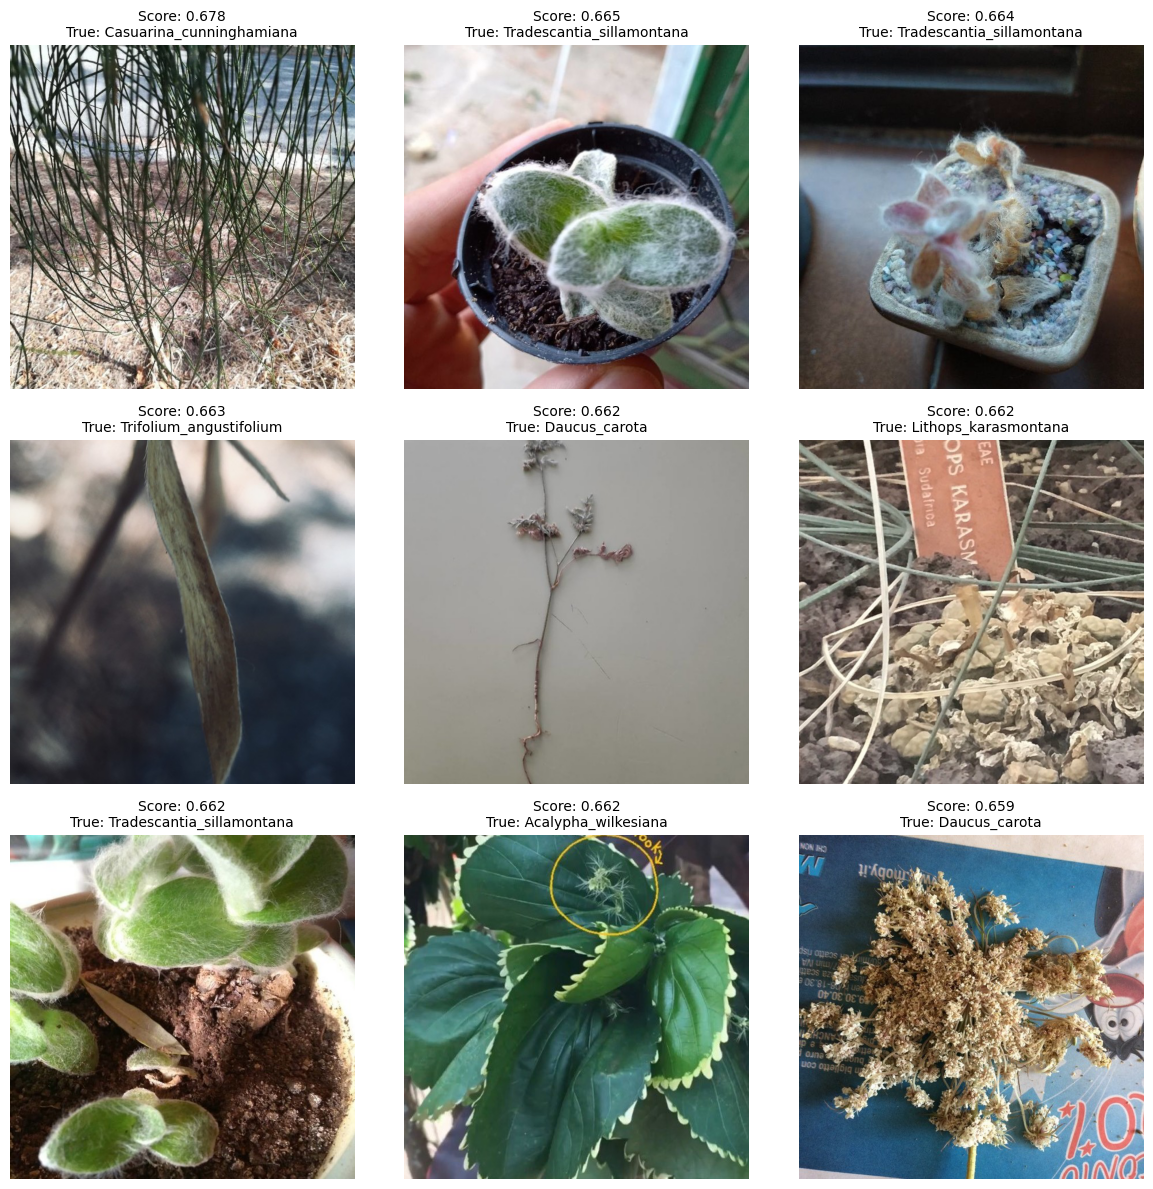

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Configure the target class
target_class = "a photo of a dried plant"  

# Find indices where this class was the top match and sort them by confidence
target_indices = np.where(top_labels == target_class)[0]
sorted_target_indices = sorted(target_indices, key=lambda idx: top_scores[idx], reverse=True)

print(f"Plotting top matches for: '{target_class}'")

# Create a 3x3 grid layout
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

# We can only show up to 9 images in a 3x3 grid
num_to_show = min(len(sorted_target_indices), 9)

for i in range(9):
    ax = axes[i]
    
    if i < num_to_show:
        idx = sorted_target_indices[i]
        
        path = img_meta[idx]["image_path"]
        score = top_scores[idx]
        true_label = img_meta[idx]["latin_name"]
        
        # Open the image if the path exists
        if os.path.exists(path):
            img = Image.open(path)
            ax.imshow(img)
            # Add text labels on top of the image subplot
            ax.set_title(f"Score: {score:.3f}\nTrue: {true_label}", fontsize=10)
        else:
            # Fallback if image path was broken
            ax.text(0.5, 0.5, "Image file not found", ha='center', va='center')
            ax.set_title(f"Score: {score:.3f}\nMissing Data", fontsize=10)
            
    # Hide the x and y axis ticks/borders for a cleaner visual layout
    ax.axis('off')

# Ensure the subplots don't squish the text labels
plt.tight_layout()
plt.show()
